# Visualization :)

In [1]:
# Loading libraries
import pandas as pd

In [2]:
# Reading SenseMat and TrackIR data:
trackir_file_path = "recordings\\processed_sensemat_data\\20260323T153346-head-sensemat-serial-log_processed.csv"
trackir_df = pd.read_csv(trackir_file_path, sep=",", comment="#")
trackir_df.head()

,RECV_TIME,TRIG_CNT,B_TIME,S_0_0,S_0_1,S_0_2,S_0_3,S_0_4,S_0_5,S_0_6,...,TTL_6,TTL_7,TTL_8,TTL_9,TTL_10,TTL_11,TTL_12,TTL_13,TTL_14,TTL_15
0,1.774276e+09,1,31375,266.0,258.0,303.0,314.0,432.0,249.0,298.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,1.774276e+09,2,60483,290.0,240.0,282.0,308.0,432.0,218.0,280.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
2,1.774276e+09,3,93684,304.0,215.0,273.0,289.0,434.0,205.0,274.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
3,1.774276e+09,4,118685,304.0,218.0,272.0,299.0,442.0,203.0,285.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
4,1.774276e+09,5,143685,309.0,226.0,281.0,299.0,450.0,210.0,280.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0


In [3]:
# Displaying columns 3 to 5:
sensor_points = trackir_df.iloc[:, 3:131]
sensor_points.head()

,S_0_0,S_0_1,S_0_2,S_0_3,S_0_4,S_0_5,S_0_6,S_0_7,S_0_8,S_0_9,...,S_7_6,S_7_7,S_7_8,S_7_9,S_7_10,S_7_11,S_7_12,S_7_13,S_7_14,S_7_15
0,266.0,258.0,303.0,314.0,432.0,249.0,298.0,245.0,409.0,269.0,...,336.0,409.0,309.0,509.0,356.0,267.0,219.0,288.0,217.0,238.0
1,290.0,240.0,282.0,308.0,432.0,218.0,280.0,216.0,403.0,213.0,...,241.0,317.0,246.0,430.0,289.0,209.0,154.0,257.0,120.0,194.0
2,304.0,215.0,273.0,289.0,434.0,205.0,274.0,208.0,426.0,208.0,...,230.0,307.0,225.0,422.0,275.0,200.0,142.0,221.0,134.0,165.0
3,304.0,218.0,272.0,299.0,442.0,203.0,285.0,206.0,419.0,216.0,...,236.0,329.0,225.0,432.0,274.0,174.0,129.0,215.0,124.0,183.0
4,309.0,226.0,281.0,299.0,450.0,210.0,280.0,199.0,416.0,198.0,...,230.0,310.0,206.0,412.0,263.0,174.0,118.0,220.0,137.0,168.0


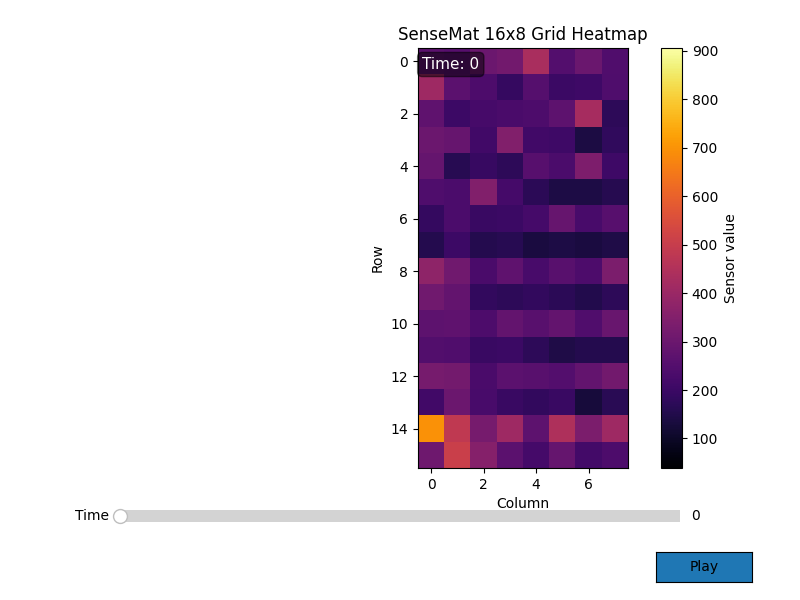

In [5]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Button, Slider

sensor_values = sensor_points.astype(float).values
n_times, n_gridpoints = sensor_values.shape

grid_shape = (16, 8)
if n_gridpoints != grid_shape[0] * grid_shape[1]:
    raise ValueError(
        f"Expected {grid_shape[0] * grid_shape[1]} gridpoints for a {grid_shape} grid, got {n_gridpoints}"
    )

frame0 = sensor_values[0].reshape(grid_shape)

vmin, vmax = np.nanmin(sensor_values), np.nanmax(sensor_values)
fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.22, top=0.92, right=0.95)

im = ax.imshow(
    frame0,
    aspect='equal',
    cmap='inferno',
    interpolation='nearest',
    vmin=vmin,
    vmax=vmax,
)

ax.set_title('SenseMat 16x8 Grid Heatmap')
ax.set_xlabel('Column')
ax.set_ylabel('Row')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Sensor value')

time_text = ax.text(
    0.02,
    0.95,
    'Time: 0',
    transform=ax.transAxes,
    color='white',
    fontsize=11,
    bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'),
)

slider_ax = plt.axes([0.15, 0.12, 0.7, 0.04], facecolor='lightgoldenrodyellow')
slider = Slider(
    ax=slider_ax,
    label='Time',
    valmin=0,
    valmax=n_times - 1,
    valinit=0,
    valstep=1,
    color='tab:orange',
)

button_ax = plt.axes([0.82, 0.03, 0.12, 0.05])
play_button = Button(button_ax, 'Play', color='tab:blue', hovercolor='tab:cyan')


def update_plot(time_index):
    time_index = int(time_index)
    frame = sensor_values[time_index].reshape(grid_shape)
    im.set_data(frame)
    time_text.set_text(f'Time: {time_index}')
    fig.canvas.draw_idle()


slider.on_changed(update_plot)

anim = FuncAnimation(
    fig,
    lambda frame: update_plot(frame),
    frames=np.arange(n_times),
    interval=200,
    repeat=True,
)
anim.event_source.stop()


is_playing = {'value': False}

def toggle_play(event):
    if is_playing['value']:
        anim.event_source.stop()
        play_button.label.set_text('Play')
        is_playing['value'] = False
    else:
        anim.event_source.start()
        play_button.label.set_text('Pause')
        is_playing['value'] = True


play_button.on_clicked(toggle_play)

plt.show()
